#Installation

SevenNet can be easily installed via pip.

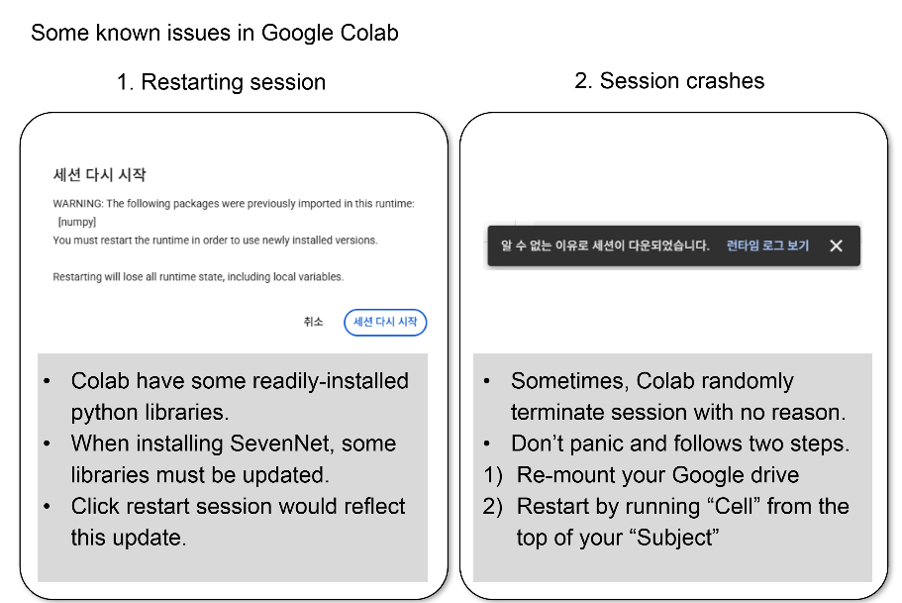

In [1]:
!pip install sevenn==0.11.2

Check whether your installation is successful

In [2]:
from sevenn.logger import Logger
logger = Logger(screen=True)
logger.greeting()

SevenNet: Scalable EquiVariance-Enabled Neural Network
version 0.11.2, Wed Nov 19 04:13:42 2025

                ****
              ********                                   .
              *//////,  ..                               .            ,*.
               ,,***.         ..                        ,          ********.                                  ./,
             .      .                ..   /////.       .,       . */////////                               /////////.
        .&@&/        .                  .(((((((..     /           *//////*.  ...                         *((((((((((.
     @@@@@@@@@@*    @@@@@@@@@@  @@@@@    *((@@@@@     (     %@@@@@@@@@@  .@@@@@@     ..@@@@.   @@@@@@*    .(@@@@@(((*
    @@@@@.          @@@@         @@@@@ .   @@@@@      #     %@@@@         @@@@@@@@     @@@@(,  @@@@@@@@.    @@@@@(*.
    %@@@@@@@&       @@@@@@@@@@    @@@@@   @@@@@      #  ., .%@@@@@@@@@    @@@@@@@@@@   @@@@,   @@@@@@@@@@   @@@@@
    ,(%@@@@@@@@@    @@@@@@@@@@     @@@@@ @@@@&   

# Obtain files from github

In [3]:
!git clone https://github.com/MDIL-SNU/sevennet_tutorial.git

prefix = 'sevennet_tutorial/CMSS_DFT_2025/'

Cloning into 'sevennet_tutorial'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 195 (delta 13), reused 26 (delta 6), pack-reused 156 (from 2)
Receiving objects: 100% (195/195), 52.47 MiB | 10.82 MiB/s, done.
Resolving deltas: 100% (73/73), done.


Confirm mounting and directories are successful

In [4]:
from ase.io import read
from ase.visualize import view
atoms = read(f'{prefix}/data/600K.extxyz')
view(atoms, viewer='x3d')

#0. The pretrained model contains errors and requires further augmentation

Evaluating 7net-0: 100%|██████████| 20/20 [00:05<00:00,  3.54it/s]


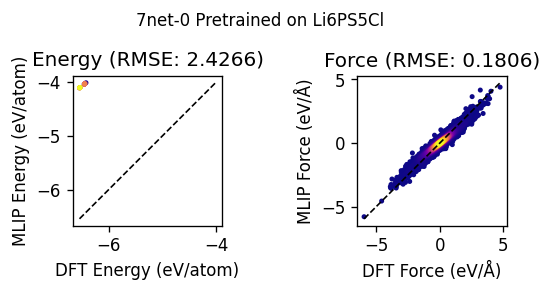

Energy RMSE: 2.426589 eV/atom | Force RMSE: 0.180637 eV/Å


In [5]:
# Evaluate pretrained 7net-0 on argyrodite and visualize errors
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from ase.io import read
from ase.units import bar
from tqdm import tqdm
from sevenn.calculator import SevenNetCalculator

prefix = 'sevennet_tutorial/CMSS_DFT_2025/'

# Load and sample test data (10%)
test_traj = read(f'{prefix}/data/test_md.extxyz', ':')
np.random.seed(42)
indices = np.random.choice(len(test_traj), int(len(test_traj)*0.1), replace=False)
traj = [test_traj[i] for i in np.sort(indices)]

# Get DFT and MLIP predictions
dft_e, dft_f, mlip_e, mlip_f = [], [], [], []
calc = SevenNetCalculator('7net-0')

for atoms in tqdm(traj, desc='Evaluating 7net-0'):
    dft_e.append(atoms.get_potential_energy() / len(atoms))
    dft_f.extend(atoms.get_forces().flatten())
    atoms.calc = calc
    mlip_e.append(atoms.get_potential_energy() / len(atoms))
    mlip_f.extend(atoms.get_forces().flatten())
    atoms.calc = None

# Calculate RMSE
rmse = lambda x, y: np.sqrt(np.mean((np.array(x)-np.array(y))**2))
e_rmse, f_rmse = rmse(dft_e, mlip_e), rmse(dft_f, mlip_f)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12/2.54, 6/2.54), dpi=120)
for ax, (x, y, label, unit, r) in zip([ax1, ax2], [
    (dft_e, mlip_e, 'Energy', 'eV/atom', e_rmse),
    (dft_f, mlip_f, 'Force', 'eV/Å', f_rmse)
]):
    x, y = np.array(x), np.array(y)
    idx = np.random.choice(len(x), min(1000, len(x)), replace=False) if len(x) > 1000 else range(len(x))
    kde = gaussian_kde(np.vstack([x[idx], y[idx]]))
    z = kde.pdf(np.vstack([x, y]))
    idx = z.argsort()
    ax.scatter(x[idx], y[idx], c=z[idx], s=4, cmap='plasma')
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlabel(f'DFT {label} ({unit})')
    ax.set_ylabel(f'MLIP {label} ({unit})')
    ax.set_title(f'{label} (RMSE: {r:.4f})')
    ax.set_aspect('equal')

plt.suptitle('7net-0 Pretrained on Li6PS5Cl', fontsize=10)
plt.tight_layout()
plt.show()
print(f"Energy RMSE: {e_rmse:.6f} eV/atom | Force RMSE: {f_rmse:.6f} eV/Å")

#1. Fine-tuning

First, let's build model from checkpoint.

Unlike training from scratch, model weights are read from the values contained in the checkpoint.

In [5]:
import sevenn.util as util


model, config = util.model_from_checkpoint(f'{prefix}/pretrained/checkpoint_small.pth')

Next, let's load the dataset.

In this case, we will use only 1/4 of the total training set.

In [6]:
from torch_geometric.loader import DataLoader

from sevenn.train.graph_dataset import SevenNetGraphDataset


data_paths = [f'{prefix}/data/600K.extxyz', f'{prefix}/data/1200K.extxyz']
dataset = SevenNetGraphDataset(
    cutoff=config['cutoff'], files=data_paths, drop_info=False
)
num_dataset = len(dataset)
num_train = int(num_dataset * 0.25)
num_valid = 10

dataset = dataset.shuffle()
trainset = dataset[:num_train]
validset = dataset[num_train:num_train + 10]

train_loader = DataLoader(trainset, batch_size=4, shuffle=True)
valid_loader = DataLoader(validset, batch_size=4)

Processing...
run_stat: 100%|██████████| 170/170 [00:00<00:00, 1118.28it/s]


Dataset is saved: ./sevenn_data/graph.pt


Done!


Here, we define hyperparameters for the fine-tuning.

In [7]:
from copy import deepcopy
import torch.optim.lr_scheduler as scheduler

from sevenn.error_recorder import ErrorRecorder
from sevenn.train.trainer import Trainer


config.update({
    'optimizer': 'adam',
    'optim_param': {'lr': 0.004},
    'scheduler': 'linearlr',
    'scheduler_param': {
        'start_factor': 1.0, 'total_iters': 10, 'end_factor': 0.0001
    },
    'is_ddp': False,  # 7net-0 is traied with ddp=True.
                      # We override this key False as we won't use it
    'loss': 'huber',
    'loss_param': {'delta': 0.01},
    'force_loss_weight': 0.1,
    'stress_loss_weight': 0.01,
})
trainer = Trainer.from_config(model, config)

train_recorder = ErrorRecorder.from_config(config)
valid_recorder = deepcopy(train_recorder)

Following script will fine-tune SevenNet-0-small with small epoch.

After training, we can save fine-tuned model to the checkpoint.

In [8]:
import os

import torch

from sevenn.logger import Logger


valid_best = float('inf')
total_epoch = 10

# As error recorder is long, let's use sevennet_logger for pretty print
# It is similar to outputs when using sevennet with terminal.
with Logger(filename='log.sevenn', screen=True) as logger:
  logger.greeting()  # prints ascii logo
  for epoch in range(total_epoch):
    logger.timer_start('epoch')
    # trainer scans whole data from given loader,
    # and updates error recorder with outputs.
    trainer.run_one_epoch(
        train_loader, is_train=True, error_recorder=train_recorder
    )
    trainer.run_one_epoch(
        valid_loader, is_train=False, error_recorder=valid_recorder
    )
    trainer.scheduler_step()
    train_err = train_recorder.epoch_forward()  # return averaged error & reset
    valid_err = valid_recorder.epoch_forward()
    logger.bar()
    logger.writeline(
        f'Epoch {epoch+1}/{total_epoch}  Learning rate: {trainer.get_lr()}'
    )
    logger.write_full_table([train_err, valid_err], ['Train', 'Valid'])
    logger.timer_end('epoch', message=f'Epoch {epoch+1} elapsed')

trainer.write_checkpoint(
    f'{prefix}/checkpoint_fine_tuned.pth', config=config, epoch=total_epoch
)

torch.cuda.empty_cache()

SevenNet: Scalable EquiVariance-Enabled Neural Network
version 0.11.2, Wed Nov 19 02:19:15 2025

                ****
              ********                                   .
              *//////,  ..                               .            ,*.
               ,,***.         ..                        ,          ********.                                  ./,
             .      .                ..   /////.       .,       . */////////                               /////////.
        .&@&/        .                  .(((((((..     /           *//////*.  ...                         *((((((((((.
     @@@@@@@@@@*    @@@@@@@@@@  @@@@@    *((@@@@@     (     %@@@@@@@@@@  .@@@@@@     ..@@@@.   @@@@@@*    .(@@@@@(((*
    @@@@@.          @@@@         @@@@@ .   @@@@@      #     %@@@@         @@@@@@@@     @@@@(,  @@@@@@@@.    @@@@@(*.
    %@@@@@@@&       @@@@@@@@@@    @@@@@   @@@@@      #  ., .%@@@@@@@@@    @@@@@@@@@@   @@@@,   @@@@@@@@@@   @@@@@
    ,(%@@@@@@@@@    @@@@@@@@@@     @@@@@ @@@@&   

#2. Application 1: Single-point calculation

`ASE` provides simulation interface for MLIPs using `Calculator` object in python.

Many MLIP packages provides custom `Calculator` objects, including SevenNet

SevenNet calculator can be obtained by followings:

```
from sevenn.calculator import SevenNetCalculator
calc = SevenNetCalculator({checkpoint_path})
...
```

for `checkpoint_path`, one should provide
- Path / file name of generated checkpoint.pth file
- Name of pretrained models (e.g., 7net-0)

Further details using `Calculator` object can be found in `ASE` documentation

(https://wiki.fysik.dtu.dk/ase/gettingstarted/tut01_molecule/molecule.html)

In this example, let's calculate energy, force, stress of *ab initio* MD simulation trajectories of another supercell, and compare the accuracy with respect to the DFT.

We have total 2 models.

- 7net-0-small: Pretrained SevenNet
- 7net-FT: Fine-tuned model from 7net-0-small

In [28]:
import numpy as np
from tqdm import tqdm
from ase.io import read
from ase.units import bar

from sevenn.calculator import SevenNetCalculator

labels = ['7net-0-small', '7net-FT']

dft_energy, dft_forces, dft_stress = [], [], []
mlip_energy_dct = {label: [] for label in labels}
mlip_forces_dct = {label: [] for label in labels}
mlip_stress_dct = {label: [] for label in labels}
to_kBar = 1/bar/1000

label_cpt_path_map = {
    '7net-0-small': f'{prefix}/pretrained/checkpoint_small.pth',
    '7net-0-shift': f'{prefix}/checkpoint_shift.pth',
    '7net-FT': f'{prefix}/checkpoint_fine_tuned.pth',
    '7net-FT-shift': f'{prefix}/checkpoint_fine_tuned_shift.pth',
}

traj = read(f'{prefix}/data/test_md.extxyz', ':')
for atoms in tqdm(traj, desc='DFT'):
    dft_energy.append(atoms.get_potential_energy() / len(atoms))
    dft_forces.extend(atoms.get_forces().flatten())
    dft_stress.extend(atoms.get_stress().flatten() * to_kBar)

for label in labels:
    calc = SevenNetCalculator(label_cpt_path_map[label])
    for atoms in tqdm(traj, desc=label):
# You can change here-----------------------------------------------------------------------


# ------------------------------------------------------------------------------------------

    del calc

7net-FT: 100%|██████████| 200/200 [00:14<00:00, 14.25it/s]


Let's plot the correlation between DFT and each model on the single-point calculated energy, force, and stress.

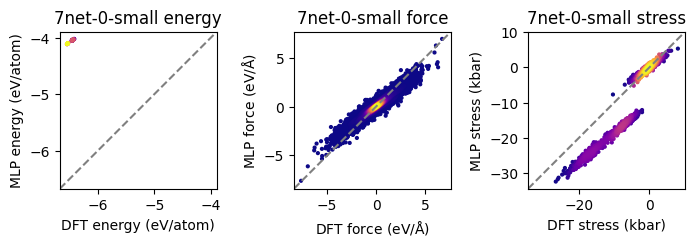

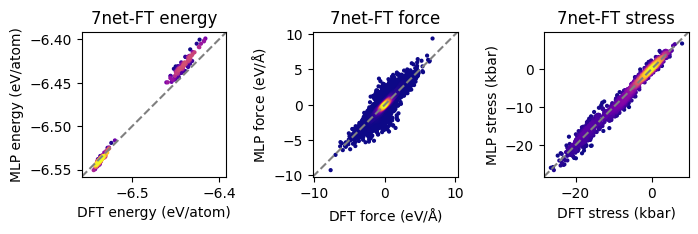

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# draw a parity plot of energy / force / stress
unit = {"energy": "eV/atom", "force": r"eV/$\rm{\AA}$", "stress": "kbar"}
def density_colored_scatter_plot(
    dft_energy,
    nnp_energy,
    dft_force,
    nnp_force,
    dft_stress,
    nnp_stress,
    title=None
):
    modes = ['energy', 'force', 'stress']
    plt.figure(figsize=(18/2.54, 6/2.54))
    for num, (x, y) in enumerate(
        zip(
            [dft_energy, dft_force, dft_stress],
            [nnp_energy, nnp_force, nnp_stress]
        )
    ):
        mode = modes[num]
        idx = (
            np.random.choice(len(x), 1000)
            if len(x) > 1000
            else list(range(len(x)))
        )
        xsam = [x[i] for i in idx]
        ysam = [y[i] for i in idx]
        xy = np.vstack([x, y])
        xysam = np.vstack([xsam, ysam])
        zsam = gaussian_kde(xysam)

        z = zsam.pdf(xy)
        idx = z.argsort()

        x = [x[i] for i in idx]
        y = [y[i] for i in idx]
        z = [z[i] for i in idx]

        ax = plt.subplot(int(f'13{num+1}'))
        plt.scatter(x, y, c=z, s=4, cmap='plasma')

        mini = min(min(x), min(y))
        maxi = max(max(x), max(y))
        ran = (maxi-mini) / 20
        plt.plot(
            [mini-ran, maxi+ran],
            [mini-ran, maxi+ran],
            color='grey',
            linestyle='dashed'
        )
        plt.xlim(mini-ran, maxi+ran)
        plt.ylim(mini-ran, maxi+ran)

        plt.xlabel(f'DFT {mode} ({unit[mode]})')
        plt.ylabel(f'MLP {mode} ({unit[mode]})')
        ax.set_aspect('equal')
        if title:
          ax.set_title(f'{title} {mode}')
    plt.tight_layout()
    plt.show()

for label in labels:
    density_colored_scatter_plot(
        dft_energy,
        mlip_energy_dct[label],
        dft_forces,
        mlip_forces_dct[label],
        dft_stress,
        mlip_stress_dct[label],
        label,
    )

In [23]:
# Compare RMSE for all models
"""
Performance Comparison Table
-----------------------------
Compare RMSE and MAE for energy, force, and stress across all models.
"""

def calculate_errors(y_true, y_pred):
    """Calculate RMSE and MAE"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
# You can change here-----------------------------------------------------------------------


# ------------------------------------------------------------------------------------------
    return rmse, mae

print("=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)

# Calculate errors for all models
results = {}
for label in labels:
    energy_rmse, energy_mae = calculate_errors(dft_energy, mlip_energy_dct[label])
    force_rmse, force_mae = calculate_errors(dft_forces, mlip_forces_dct[label])
    stress_rmse, stress_mae = calculate_errors(dft_stress, mlip_stress_dct[label])

    results[label] = {
        'energy_rmse': energy_rmse,
        'energy_mae': energy_mae,
        'force_rmse': force_rmse,
        'force_mae': force_mae,
        'stress_rmse': stress_rmse,
        'stress_mae': stress_mae,
    }

# Print Energy comparison
print("\n📊 ENERGY PREDICTION (eV/atom)")
print("-" * 90)
print(f"{'Model':<20} {'RMSE':>15} {'MAE':>15}")
print("-" * 90)
for label in labels:
    print(f"{label:<20} {results[label]['energy_rmse']:>15.6f} {results[label]['energy_mae']:>15.6f}")
print("-" * 90)

# Print Force comparison
print("\n📊 FORCE PREDICTION (eV/Å)")
print("-" * 90)
print(f"{'Model':<20} {'RMSE':>15} {'MAE':>15}")
print("-" * 90)
for label in labels:
    print(f"{label:<20} {results[label]['force_rmse']:>15.6f} {results[label]['force_mae']:>15.6f}")
print("-" * 90)

# Print Stress comparison
print("\n📊 STRESS PREDICTION (kbar)")
print("-" * 90)
print(f"{'Model':<20} {'RMSE':>15} {'MAE':>15}")
print("-" * 90)
for label in labels:
    print(f"{label:<20} {results[label]['stress_rmse']:>15.6f} {results[label]['stress_mae']:>15.6f}")
print("-" * 90)

# Calculate improvement percentages
if len(labels) == 2:
    print("\n💡 IMPROVEMENT ANALYSIS")
    print("=" * 90)
    base_label = labels[0]
    ft_label = labels[1]

    energy_improve = (results[base_label]['energy_rmse'] - results[ft_label]['energy_rmse']) / results[base_label]['energy_rmse'] * 100
    force_improve = (results[base_label]['force_rmse'] - results[ft_label]['force_rmse']) / results[base_label]['force_rmse'] * 100
    stress_improve = (results[base_label]['stress_rmse'] - results[ft_label]['stress_rmse']) / results[base_label]['stress_rmse'] * 100

    print(f"\nComparing {ft_label} vs {base_label}:")
    print(f"  Energy RMSE improvement: {energy_improve:>8.2f}%")
    print(f"  Force RMSE improvement:  {force_improve:>8.2f}%")
    print(f"  Stress RMSE improvement: {stress_improve:>8.2f}%")
    print("=" * 90)

MODEL PERFORMANCE COMPARISON

📊 ENERGY PREDICTION (eV/atom)
------------------------------------------------------------------------------------------
Model                           RMSE             MAE
------------------------------------------------------------------------------------------
7net-0-small                2.412241        2.412200
7net-FT-shift               0.002657        0.002019
------------------------------------------------------------------------------------------

📊 FORCE PREDICTION (eV/Å)
------------------------------------------------------------------------------------------
Model                           RMSE             MAE
------------------------------------------------------------------------------------------
7net-0-small                0.240168        0.167609
7net-FT-shift               0.117292        0.081602
------------------------------------------------------------------------------------------

📊 STRESS PREDICTION (kbar)
---------------------

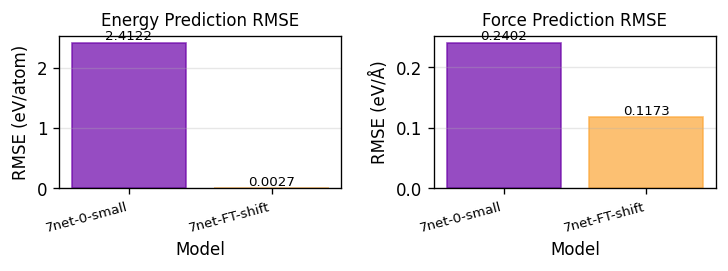

✓ RMSE comparison plots generated


In [26]:
# Visualize RMSE comparison with bar plot
"""
RMSE Comparison Bar Plot
-------------------------
Visual comparison of RMSE values across models.
"""

fig, axes = plt.subplots(1, 2, figsize=(16/2.54, 6/2.54), dpi=120)

properties = ['Energy', 'Force']
units = ['eV/atom', 'eV/Å']
metrics = ['energy_rmse', 'force_rmse']

for idx, (prop, unit, metric) in enumerate(zip(properties, units, metrics)):
    ax = axes[idx]

    # Extract RMSE values
    model_names = labels
    rmse_values = [results[label][metric] for label in labels]

    # Create bar plot
    x_pos = np.arange(len(model_names))
    bars = ax.bar(x_pos, rmse_values, alpha=0.7, edgecolor='black', linewidth=1)

    # Color bars
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(model_names)))
    for bar, color in zip(bars, colors):
        bar.set_color(color)

    # Add value labels on top of bars
    for i, (bar, val) in enumerate(zip(bars, rmse_values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)

    # Formatting
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylabel(f'RMSE ({unit})', fontsize=10)
    ax.set_title(f'{prop} Prediction RMSE', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # Set y-axis to start from 0
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("✓ RMSE comparison plots generated")

#Application 2: Geometric relaxation

From now on, we will utilize 7net-FT-shift as a base model.

Geometric relaxation is a task that finds the local energy minimum at given potential energy surface (PES) near the initial configuration.

This can be done by using ASE modules, combining `Optimizer`, `Filter` and `Calculator` object.

- `Optimizer` gives the algorithm for energy minimization
- `Filter` gives more advanced feature of relaxation (e.g, relax both atomic position and cell size, ISIF=3 in VASP)
- `Calculator` gives PES, just like described in Appl. 1.

For more information, please check:

https://wiki.fysik.dtu.dk/ase/ase/optimize.html

https://wiki.fysik.dtu.dk/ase/ase/filters.html

First, let's call the SevenNetCalculator.

In [18]:
from sevenn.calculator import SevenNetCalculator

# Load the fine-tuned model
# You can change here-----------------------------------------------------------------------

calc = SevenNetCalculator(f'{prefix}/checkpoint_')

# ------------------------------------------------------------------------------------------

Next, we can relax a Argyrodite supercell.

       Step     Time          Energy          fmax
LBFGS:    0 02:25:55    -2680.233887        6.370532
LBFGS:    1 02:25:55    -2687.835938        2.645609
LBFGS:    2 02:25:56    -2703.754883        3.337123
LBFGS:    3 02:25:56    -2710.393555        4.566490
LBFGS:    4 02:25:56    -2715.573730        4.131353
LBFGS:    5 02:25:56    -2719.255371        2.559659
LBFGS:    6 02:25:56    -2722.079834        1.620424
LBFGS:    7 02:25:56    -2724.795410        3.328759
LBFGS:    8 02:25:57    -2727.113525        4.903670
LBFGS:    9 02:25:57    -2729.919189        2.055325
LBFGS:   10 02:25:57    -2731.026367        1.694253
LBFGS:   11 02:25:57    -2732.635742        2.297444
LBFGS:   12 02:25:57    -2733.640625        2.523357
LBFGS:   13 02:25:57    -2735.164795        1.316385
LBFGS:   14 02:25:57    -2736.028809        1.134312
LBFGS:   15 02:25:57    -2736.976562        1.364033
LBFGS:   16 02:25:58    -2737.645020        1.495918
LBFGS:   17 02:25:58    -2738.333008        1.09

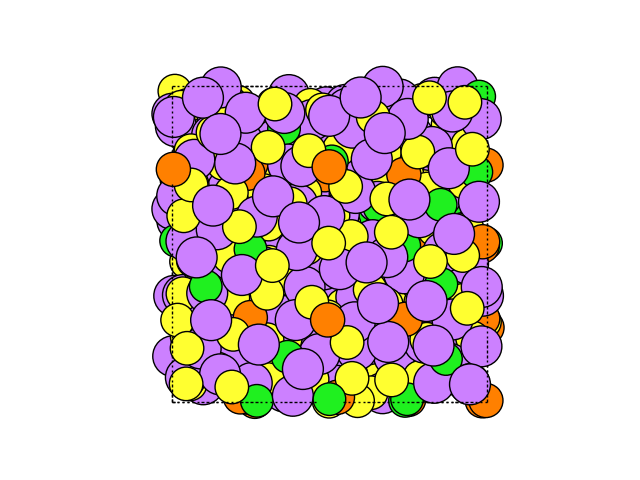

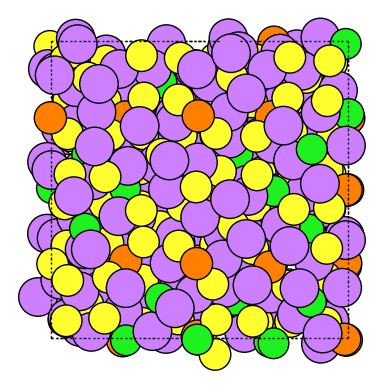

In [19]:
from IPython.display import Image

from ase.io import read, write, Trajectory
from ase.optimize import LBFGS  # Optimizer
from ase.filters import FrechetCellFilter  # Filter

atoms = read(f'{prefix}/data/test_md.extxyz', 0)
atoms.calc = calc

cf = FrechetCellFilter(atoms, hydrostatic_strain=True)
opt = LBFGS(cf, trajectory=f'{prefix}/relax.traj')
opt.run(fmax=0.05, steps=1000)

traj = Trajectory(f'{prefix}/relax.traj')
possible = []
for i in range(len(traj)):
    try:
        possible.append(traj[i])
    except:
        pass
write(f'{prefix}/relax.gif', possible[::10])
write(f'{prefix}/relax.extxyz', atoms)

vol = atoms.get_cell().volume / 8 # 222 supercell
print(f'Relaxed volume per unit cell = {vol} Å³')
print(f'Experimental volume per unit cell = 956 - 960 Å³')

Image(open(f'{prefix}/relax.gif', 'rb').read())

#Application 3: NVT MD simulation

From relaxed geometries, let's run MD simulation at constant temperature and volume.

In ASE, they provide various NVT ensembls, such as Langevin, Nose-Hoover, and etc.

For more information please follow:

https://wiki.fysik.dtu.dk/ase/ase/md.html

Here, we will run Langevin dynamics at 600 K.

While MD, let's check the diffusivity of each atoms.


In [20]:
from IPython.display import Image
import numpy as np

from ase.io import read
from ase import units
from ase.md import MDLogger
from ase.md.langevin import Langevin

from sevenn.calculator import SevenNetCalculator

# Load the fine-tuned model
# You can change here-----------------------------------------------------------------------
calc = SevenNetCalculator(f'{prefix}/checkpoint_')
# ------------------------------------------------------------------------------------------
atoms = read(f'{prefix}/relax.extxyz')
atoms.calc = calc
atoms.set_momenta(
    np.random.normal(
        scale=np.sqrt(units.kB * 600 * atoms.get_masses()[:, None]),
        size=(len(atoms), 3)
    )
)
timestep = 2 * units.fs  # 1 femtosecond
friction = 0.01 / units.fs  # Friction coefficient
dyn = Langevin(
    atoms,
    timestep,
    trajectory=f'{prefix}/nvt_md.traj',
    temperature_K=600,
    friction=friction
)

logger = MDLogger(dyn, atoms, '-', header=True, stress=True, peratom=True)
dyn.attach(logger, interval=10)
dyn.run(1000)

Time[ps]    Etot/N[eV]   Epot/N[eV]   Ekin/N[eV]    T[K]      ---------------------- stress [GPa] -----------------------
0.0000          -6.5340      -6.6133       0.0793   613.5     -0.366     -0.441     -0.382     -0.029      0.083      0.078
0.0200          -6.5212      -6.5654       0.0442   341.6     -0.807     -0.972     -0.818      0.064      0.213     -0.065
0.0400          -6.5097      -6.5603       0.0505   391.1     -0.580     -0.681     -0.571     -0.181      0.026      0.199
0.0600          -6.4986      -6.5560       0.0574   444.4     -0.688     -0.894     -0.890     -0.248      0.060     -0.132
0.0800          -6.4914      -6.5516       0.0602   465.5     -0.864     -1.233     -1.050      0.005      0.186     -0.104
0.1000          -6.4862      -6.5502       0.0640   495.0     -0.699     -1.000     -0.893     -0.061     -0.041      0.069
0.1200          -6.4797      -6.5459       0.0662   512.3     -0.881     -1.069     -1.077      0.082      0.181      0.157
0.1400    

True

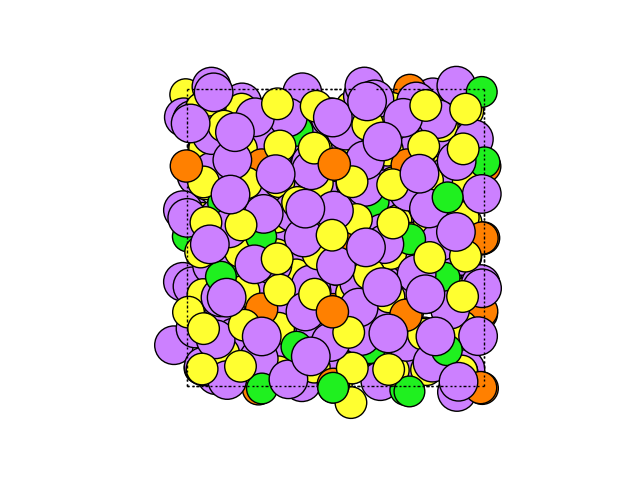

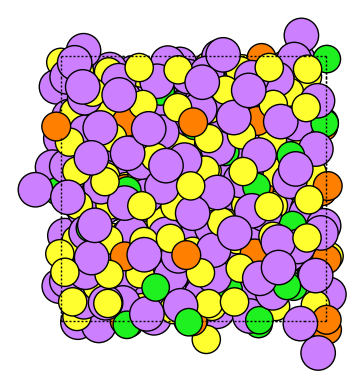

In [21]:
from ase.io import write, Trajectory


traj = Trajectory(f'{prefix}/nvt_md.traj')
possible = []
for i in range(len(traj)):
    try:
        possible.append(traj[i])
    except:
        pass
write(f'{prefix}/nvt_md.gif', possible[::50])

Image(open(f'{prefix}/nvt_md.gif', 'rb').read())

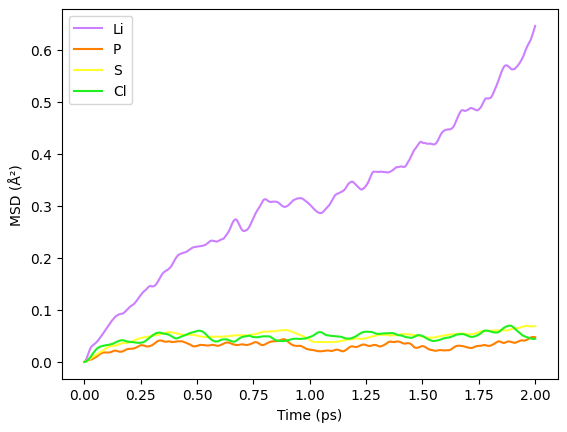

In [22]:
import matplotlib.pyplot as plt
from ase.io import write, Trajectory


traj = Trajectory(f'{prefix}/nvt_md.traj')
possible = []
for i in range(len(traj)):
    try:
        possible.append(traj[i])
    except:
        pass

init = possible[0]
init_pos = init.get_positions()
elem_types = np.array(init.get_chemical_symbols())

elems = ['Li', 'P', 'S', 'Cl']
msd = {elem: [0] for elem in elems}
time = [0]

for timestep, atoms in enumerate(possible):
    time.append(timestep*2/1000) # in ps
    for elem in elems:
        init = init_pos[elem_types==elem]
        pos = atoms.get_positions()[elem_types==elem]
        msd[elem].append(np.mean(np.square(init-pos)))

color = {
    'Li': (204/255, 128/255, 1),
    'P': (1, 128/255, 0),
    'S': (1, 1, 48/255),
    'Cl': (31/255, 240/255, 31/255),
}

plt.figure()
for elem in elems:
    plt.plot(time, msd[elem], color=color[elem], label=elem)

plt.legend()
plt.xlabel('Time (ps)')
plt.ylabel('MSD (Å²)')
plt.show()